In [25]:
import torch
import torch.nn as nn
import torch.optim as optim

import librosa
import numpy as np
from constants import *
import IPython.display as ipd
import matplotlib.pyplot as plt
from utils import stitch_wave_chunks
from stft_dataset import build_data_loaders

In [2]:
train_data_loader_real, test_data_loader_real = build_data_loaders(part="real")

In [3]:
x, y, fp_x, fp_y = next(iter(test_data_loader_real))
print(torch.min(x), torch.max(x))
print("Original shape:", x.shape)
NUM_TOTAL_FEATURES = int(x.shape[2] * x.shape[3])
print("NUM_TOTAL_FEATURES:", NUM_TOTAL_FEATURES)

print("Encoder:")
x = nn.Conv2d(1, 16, 3, stride=2)(x)
print("1", x.size())
x = nn.Conv2d(16, 32, 3, stride=2)(x)
print("2", x.size())
x = nn.BatchNorm2d(32)(x)
print("3", x.size())
x = nn.Conv2d(32, 64, 3, stride=2)(x)
print("4", x.size())
x = nn.Conv2d(64, 128, 3, stride=2)(x)
print("5", x.size())
x = nn.BatchNorm2d(128)(x)
print("6", x.size())

# decoder
print("Decoder:")
x = nn.ConvTranspose2d(128, 64, 3, stride=1)(x)
print("1", x.size())
x = nn.ConvTranspose2d(64, 32, 3, stride=1)(x)
print("2", x.size())
x = nn.ConvTranspose2d(32, 1, 3, stride=1)(x)
print("3", x.size())
x = x.view(4, -1)
print("4", x.size())
x = nn.Linear(518, NUM_TOTAL_FEATURES//16)(x)
print("5", x.size())
x = nn.Linear(NUM_TOTAL_FEATURES//16, NUM_TOTAL_FEATURES)(x)
print("6", x.shape)
x = x.view(4, 1, 512, -1)
print("7", x.size())

tensor(0.1862) tensor(0.8098)
Original shape: torch.Size([4, 1, 512, 152])
NUM_TOTAL_FEATURES: 77824
Encoder:
1 torch.Size([4, 16, 255, 75])
2 torch.Size([4, 32, 127, 37])
3 torch.Size([4, 32, 127, 37])
4 torch.Size([4, 64, 63, 18])
5 torch.Size([4, 128, 31, 8])
6 torch.Size([4, 128, 31, 8])
Decoder:
1 torch.Size([4, 64, 33, 10])
2 torch.Size([4, 32, 35, 12])
3 torch.Size([4, 1, 37, 14])
4 torch.Size([4, 518])
5 torch.Size([4, 4864])
6 torch.Size([4, 77824])
7 torch.Size([4, 1, 512, 152])


In [4]:
class Gtr_2_Ney_AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.NUM_TOTAL_FEATURES = 77824
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2),
            nn.LeakyReLU(),
            nn.Conv2d(16, 32, 3, stride=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.Conv2d(32, 64, 3, stride=2),
            nn.Sigmoid(),
            nn.Conv2d(64, 128, 3, stride=2),
            nn.BatchNorm2d(128)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=1),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=1),
            nn.LeakyReLU()
        )

        self.linear = nn.Sequential(
            nn.Linear(518, self.NUM_TOTAL_FEATURES),
            nn.Sigmoid()
            # nn.Linear(NUM_TOTAL_FEATURES//16, NUM_TOTAL_FEATURES),
            # nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = decoded.view(4, -1)
        decoded = self.linear(decoded)
        decoded = decoded.view(4, 1, 512, -1)
        return decoded

In [6]:
def train_model(part="real", lr=0.001, num_epochs=20):
    train_data_loader, test_data_loader = build_data_loaders(part=part)
    gtr_2_ney_model = Gtr_2_Ney_AutoEncoder()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(gtr_2_ney_model.parameters(), lr=lr)
    loss_graph = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        for gtr_features, ney_features, _, _ in train_data_loader:
            y_hat = gtr_2_ney_model(gtr_features)
            loss = criterion(y_hat, ney_features)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch: {epoch + 1:03d}/{num_epochs}\tLoss: {running_loss:.6f}")
        loss_graph.append(running_loss)

    return gtr_2_ney_model, test_data_loader, loss_graph

In [7]:
model_real, test_data_loader_real, loss_graph_real = train_model(
    part="real", lr=0.0005, num_epochs=30)

Epoch: 001/30	Loss: 0.374793
Epoch: 002/30	Loss: 0.016183
Epoch: 003/30	Loss: 0.012540
Epoch: 004/30	Loss: 0.011163
Epoch: 005/30	Loss: 0.010145
Epoch: 006/30	Loss: 0.009527
Epoch: 007/30	Loss: 0.009302
Epoch: 008/30	Loss: 0.009162
Epoch: 009/30	Loss: 0.009014
Epoch: 010/30	Loss: 0.008986
Epoch: 011/30	Loss: 0.008940
Epoch: 012/30	Loss: 0.008844
Epoch: 013/30	Loss: 0.008833
Epoch: 014/30	Loss: 0.008814
Epoch: 015/30	Loss: 0.008727
Epoch: 016/30	Loss: 0.008713
Epoch: 017/30	Loss: 0.008681
Epoch: 018/30	Loss: 0.008656
Epoch: 019/30	Loss: 0.008642
Epoch: 020/30	Loss: 0.008612
Epoch: 021/30	Loss: 0.008596
Epoch: 022/30	Loss: 0.008594
Epoch: 023/30	Loss: 0.008581
Epoch: 024/30	Loss: 0.008571
Epoch: 025/30	Loss: 0.008545
Epoch: 026/30	Loss: 0.008547
Epoch: 027/30	Loss: 0.008535
Epoch: 028/30	Loss: 0.008533
Epoch: 029/30	Loss: 0.008527
Epoch: 030/30	Loss: 0.008520


In [15]:
def plot_loss(loss_graph, title, yscale="linear"):
    plt.figure(figsize=(8, 4))
    plt.title(title)
    epochs = np.arange(1, len(loss_graph) + 1)
    plt.plot(epochs, loss_graph)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.yscale(yscale)
    plt.show()

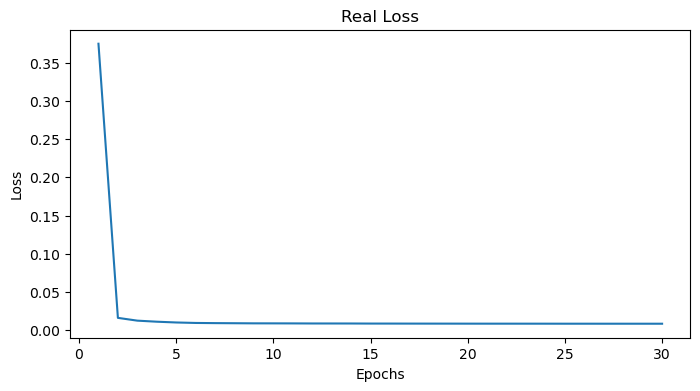

In [16]:
plot_loss(loss_graph_real, "Real Loss")

In [12]:
model_imag, test_data_loader_imag, loss_graph_imag = train_model(
    part="imag", lr=0.0005, num_epochs=30)

Epoch: 001/30	Loss: 0.028636
Epoch: 002/30	Loss: 0.008954
Epoch: 003/30	Loss: 0.008724
Epoch: 004/30	Loss: 0.008645
Epoch: 005/30	Loss: 0.008597
Epoch: 006/30	Loss: 0.008573
Epoch: 007/30	Loss: 0.008552
Epoch: 008/30	Loss: 0.008532
Epoch: 009/30	Loss: 0.008523
Epoch: 010/30	Loss: 0.008516
Epoch: 011/30	Loss: 0.008498
Epoch: 012/30	Loss: 0.008495
Epoch: 013/30	Loss: 0.008492
Epoch: 014/30	Loss: 0.008490
Epoch: 015/30	Loss: 0.008484
Epoch: 016/30	Loss: 0.008484
Epoch: 017/30	Loss: 0.008482
Epoch: 018/30	Loss: 0.008467
Epoch: 019/30	Loss: 0.008472
Epoch: 020/30	Loss: 0.008469
Epoch: 021/30	Loss: 0.008461
Epoch: 022/30	Loss: 0.008453
Epoch: 023/30	Loss: 0.008456
Epoch: 024/30	Loss: 0.008450
Epoch: 025/30	Loss: 0.008444
Epoch: 026/30	Loss: 0.008454
Epoch: 027/30	Loss: 0.008437
Epoch: 028/30	Loss: 0.008441
Epoch: 029/30	Loss: 0.008443
Epoch: 030/30	Loss: 0.008439


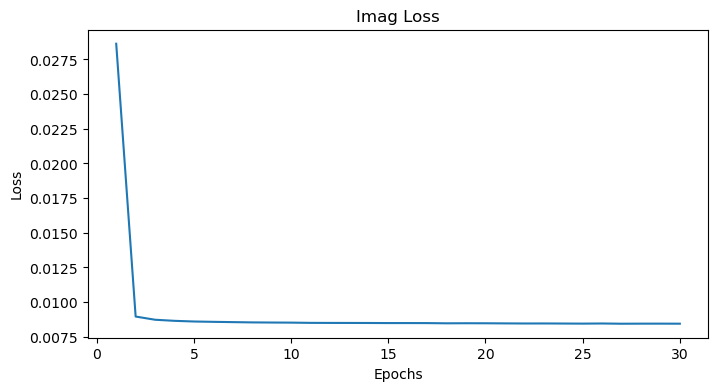

In [17]:
plot_loss(loss_graph_imag, "Imag Loss")

In [23]:
def predict(model, test_data_loader):
    x, y, x_paths, y_paths = next(iter(test_data_loader))
    print(x_paths)
    print(y_paths)
    print("-" * 20)
    predicted_chunks = None
    with torch.no_grad():
        predicted_chunks = model(x).numpy()
    predicted_chunks = (np.squeeze(predicted_chunks, axis=1) * 400.0) - 200.0
    target_chunks = (np.squeeze(y.numpy(), axis=1) * 400.0) - 200.0
    return predicted_chunks, target_chunks

In [24]:
predicted_chunks_real, target_chunks_real = predict(
    model_real, test_data_loader_real)
predicted_chunks_imag, target_chunks_imag = predict(
    model_imag, test_data_loader_imag)

('dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_0', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_1', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_2', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_3')
('dataset/features/ney/08_Ney_G_S_3/chunk_0', 'dataset/features/ney/08_Ney_G_S_3/chunk_1', 'dataset/features/ney/08_Ney_G_S_3/chunk_2', 'dataset/features/ney/08_Ney_G_S_3/chunk_3')
--------------------
('dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_0', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_1', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_2', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_3')
('dataset/features/ney/08_Ney_G_S_3/chunk_0', 'dataset/features/ney/08_Ney_G_S_3/chunk_1', 'dataset/features/ney/08_Ney_G_S_3/chunk_2', 'dataset/features/ney/08_Ney_G_S_3/chunk_3')
--------------------


In [36]:
def make_wav(real_chunks, imag_chunks):
    wave_chunks = []
    for chunk_real, chunk_imag in zip(real_chunks, imag_chunks):
        chunk = chunk_real + chunk_imag * 1j
        wave_chunk = librosa.istft(chunk, n_fft=N_FFT, hop_length=HOP)
        wave_chunk = wave_chunk[:WINDOW_SAMPLE_LEN]
        wave_chunks.append(wave_chunk)

    stitched_wave = stitch_wave_chunks(wave_chunks)
    return stitched_wave

In [37]:
wave_prediction = make_wav(predicted_chunks_real, predicted_chunks_imag)
wave_target = make_wav(target_chunks_real, target_chunks_imag)
print(len(wave_prediction), len(wave_target))

38100 38100


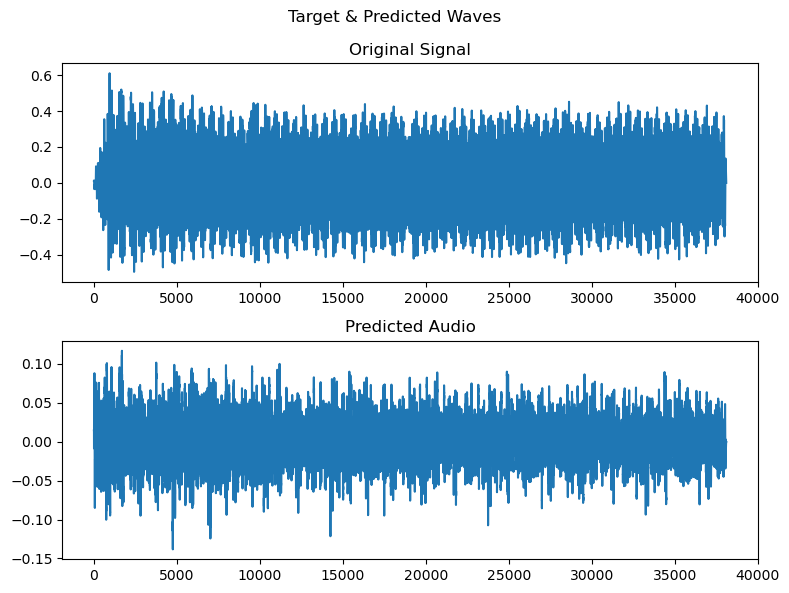

In [38]:
fig, axs = plt.subplots(2, figsize=(8, 6))
fig.suptitle("Target & Predicted Waves")
axs[0].set_title("Original Signal")
axs[0].plot(wave_target)
axs[1].set_title("Predicted Audio")
axs[1].plot(wave_prediction)
fig.tight_layout()
plt.show()

In [39]:
ipd.Audio(wave_target, rate=SR)

In [40]:
ipd.Audio(wave_prediction, rate=SR)